In [1]:
import IJulia
import Base64

# The julia kernel has built in support for Revise.jl, so this is the 
# recommended approach for long-running sessions:
# https://github.com/JuliaLang/IJulia.jl/blob/9b10fa9b879574bbf720f5285029e07758e50a5e/src/kernel.jl#L46-L51

# Users should enable revise within .julia/config/startup_ijulia.jl:
# https://timholy.github.io/Revise.jl/stable/config/#Using-Revise-automatically-within-Jupyter/IJulia-1

# clear console history
IJulia.clear_history()

fig_width = 5
fig_height = 4
fig_format = :png
fig_dpi = 96

# no retina format type, use svg for high quality type/marks
if fig_format == :retina
  fig_format = :svg
elseif fig_format == :pdf
  fig_dpi = 96
  # Enable PDF support for IJulia
  IJulia.register_mime(MIME("application/pdf"))
end

# convert inches to pixels
fig_width = fig_width * fig_dpi
fig_height = fig_height * fig_dpi

# Intialize Plots w/ default fig width/height
try
  import Plots

  # Plots.jl doesn't support PDF output for versions < 1.28.1
  # so use png (if the DPI remains the default of 300 then set to 96)
  if (Plots._current_plots_version < v"1.28.1") & (fig_format == :pdf)
    Plots.gr(size=(fig_width, fig_height), fmt = :png, dpi = fig_dpi)
  else
    Plots.gr(size=(fig_width, fig_height), fmt = fig_format, dpi = fig_dpi)
  end
catch e
  # @warn "Plots init" exception=(e, catch_backtrace())
end

# Initialize CairoMakie with default fig width/height
try
  import CairoMakie

  # CairoMakie's display() in PDF format opens an interactive window
  # instead of saving to the ipynb file, so we don't do that.
  # https://github.com/quarto-dev/quarto-cli/issues/7548
  if fig_format == :pdf
    CairoMakie.activate!(type = "png")
  else
    CairoMakie.activate!(type = string(fig_format))
  end
  CairoMakie.update_theme!(resolution=(fig_width, fig_height))
catch e
    # @warn "CairoMakie init" exception=(e, catch_backtrace())
end
  
# Set run_path if specified
try
  run_path = "L3J1bi9tZWRpYS9hbGYvZGF0b3MvbWlzcmVwb3NpdG9yaW9zL2RvY2VuY2lhL2VjdWFjaW9uZXMtZGlmZXJlbmNpYWxlcy1wcmFjdGljYXMtanVsaWE="
  if !isempty(run_path)
    run_path = String(Base64.base64decode(run_path))
    cd(run_path)
  end
catch e
  @warn "Run path init:" exception=(e, catch_backtrace())
end


# emulate old Pkg.installed beahvior, see
# https://discourse.julialang.org/t/how-to-use-pkg-dependencies-instead-of-pkg-installed/36416/9
import Pkg
function isinstalled(pkg::String)
  any(x -> x.name == pkg && x.is_direct_dep, values(Pkg.dependencies()))
end

# ojs_define
if isinstalled("JSON") && isinstalled("DataFrames")
  import JSON, DataFrames
  global function ojs_define(; kwargs...)
    convert(x) = x
    convert(x::DataFrames.AbstractDataFrame) = Tables.rows(x)
    content = Dict("contents" => [Dict("name" => k, "value" => convert(v)) for (k, v) in kwargs])
    tag = "<script type='ojs-define'>$(JSON.json(content))</script>"
    IJulia.display(MIME("text/html"), tag)
  end
elseif isinstalled("JSON")
  import JSON
  global function ojs_define(; kwargs...)
    content = Dict("contents" => [Dict("name" => k, "value" => v) for (k, v) in kwargs])
    tag = "<script type='ojs-define'>$(JSON.json(content))</script>"
    IJulia.display(MIME("text/html"), tag)
  end
else
  global function ojs_define(; kwargs...)
    @warn "JSON package not available. Please install the JSON.jl package to use ojs_define."
  end
end


# don't return kernel dependencies (b/c Revise should take care of dependencies)
nothing


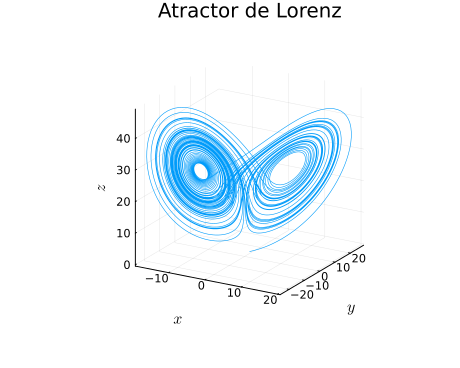

In [2]:
using Plots, LaTeXStrings, DifferentialEquations

function lorenz!(du, u, p, t)
    σ, ρ, β = p
    du[1] = σ*(u[2] - u[1])
    du[2] = u[1]*(ρ - u[3]) - u[2]
    du[3] = u[1]*u[2] - β*u[3]
end

p = (10.0, 28.0, 8/3)
sol = solve(ODEProblem(lorenz!, [1.0, 1.0, 1.0], (0.0, 60.0), p),
            saveat = 0.005)
plot(sol[1, :], sol[2, :], sol[3, :], lw = 0.6, legend = false,
    xlab = L"x", ylab = L"y", zlab = L"z", camera = (30, 20),
    title = "Atractor de Lorenz")

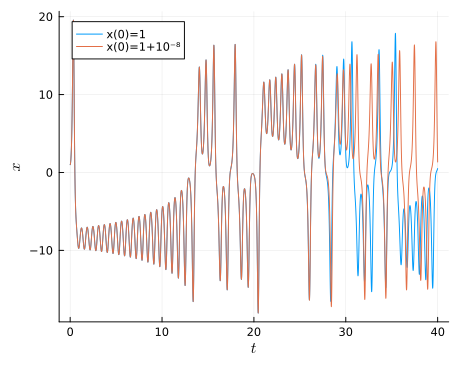

In [3]:
sol1 = solve(ODEProblem(lorenz!, [1.0, 1.0, 1.0], (0.0, 40.0), p), saveat = 0.01)
sol2 = solve(ODEProblem(lorenz!, [1.0 + 1e-8, 1.0, 1.0], (0.0, 40.0), p), saveat = 0.01)
plot(sol1.t, sol1[1, :], lw = 1, label = "x(0)=1", xlab = L"t", ylab = L"x")
plot!(sol2.t, sol2[1, :], lw = 1, label = "x(0)=1+10⁻⁸")

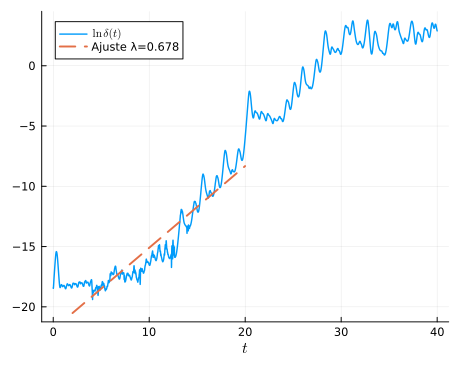

In [4]:
using LinearAlgebra
δ = [norm(sol2.u[i] - sol1.u[i]) for i in eachindex(sol1.t)]
ventana = findall(t -> 2 < t < 20, sol1.t)   # fase de crecimiento exponencial
ts = sol1.t[ventana]; logδ = log.(δ[ventana])
# Ajuste lineal por mínimos cuadrados:
A = [ts ones(length(ts))]
λ, b = A \ logδ
plot(sol1.t, log.(δ), lw = 1.5, label = L"\ln \delta(t)", xlab = L"t")
plot!(ts, λ .* ts .+ b, lw = 2, ls = :dash, label = "Ajuste λ=$(round(λ,digits=3))")

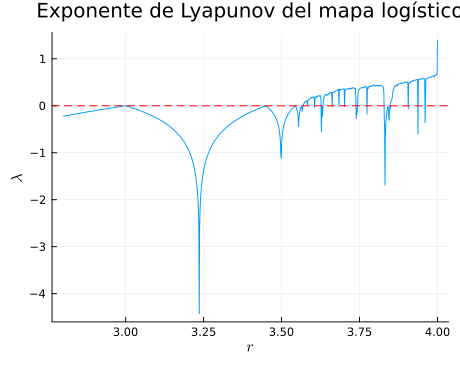

In [5]:
using Plots, LaTeXStrings

function lyapunov_log(r; ntrans = 1000, n = 10000)
    x = 0.5
    for _ in 1:ntrans; x = r*x*(1-x); end
    s = 0.0
    for _ in 1:n
        s += log(abs(r*(1 - 2x)))
        x = r*x*(1-x)
    end
    s / n
end

rs = range(2.8, 4.0, length = 1000)
λs = lyapunov_log.(rs)
plot(rs, λs, lw = 1, legend = false, xlab = L"r", ylab = L"\lambda",
    title = "Exponente de Lyapunov del mapa logístico")
hline!([0], color = :red, ls = :dash)

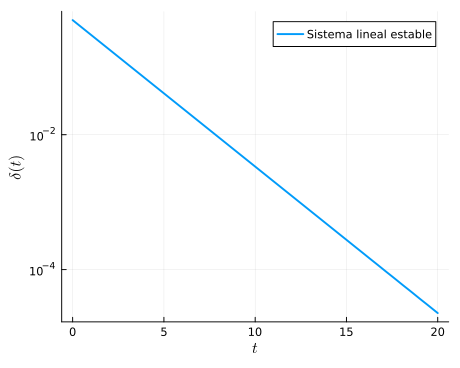

In [6]:
using Plots, LaTeXStrings, DifferentialEquations
# Sistema lineal estable: las trayectorias vecinas se juntan.
A = [-0.5 1.0; -1.0 -0.5]
sol_a = solve(ODEProblem((u,p,t)->A*u, [1.0, 0.0], (0.0, 20.0)), saveat=0.05)
sol_b = solve(ODEProblem((u,p,t)->A*u, [1.0 + 0.5, 0.0], (0.0, 20.0)), saveat=0.05)
δlin = [norm(sol_b.u[i] - sol_a.u[i]) for i in eachindex(sol_a.t)]
plot(sol_a.t, δlin, lw = 2, label = "Sistema lineal estable",
    xlab = L"t", ylab = L"\delta(t)", yscale = :log10)

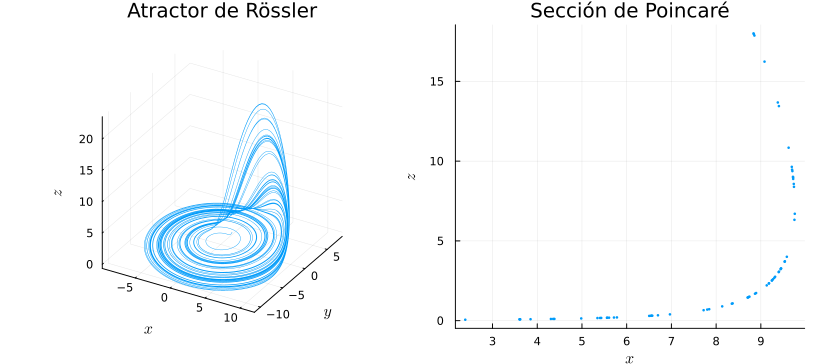

In [7]:
using Plots, LaTeXStrings, DifferentialEquations

function rossler!(du, u, p, t)
    a, b, c = p
    du[1] = -u[2] - u[3]
    du[2] = u[1] + a*u[2]
    du[3] = b + u[3]*(u[1] - c)
end

sol = solve(ODEProblem(rossler!, [1.0, 1.0, 1.0], (0.0, 400.0), (0.2, 0.2, 5.7)),
            saveat = 0.02)
p1 = plot(sol[1, :], sol[2, :], sol[3, :], lw = 0.4, legend = false,
    xlab = L"x", ylab = L"y", zlab = L"z", title = "Atractor de Rössler")

# Sección de Poincaré en y = 0 con y creciente:
xs = Float64[]; zs = Float64[]
for i in 2:length(sol.t)
    if sol[2, i-1] < 0 <= sol[2, i]
        frac = -sol[2, i-1] / (sol[2, i] - sol[2, i-1])
        push!(xs, sol[1, i-1] + frac*(sol[1, i] - sol[1, i-1]))
        push!(zs, sol[3, i-1] + frac*(sol[3, i] - sol[3, i-1]))
    end
end
p2 = scatter(xs, zs, ms = 1.5, msw = 0, legend = false,
    xlab = L"x", ylab = L"z", title = "Sección de Poincaré")
plot(p1, p2, layout = (1, 2), size = (850, 380))